# PART-A

In [472]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2

In [473]:
CRACK_DIR = "448/Cracks"
NON_CRACK_DIR = "448/NonCracks"

print("Crack folder exists:", os.path.exists(CRACK_DIR))
print("Non-crack folder exists:", os.path.exists(NON_CRACK_DIR))

Crack folder exists: True
Non-crack folder exists: True


In [474]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

crack_files = [
    os.path.join(CRACK_DIR, f)
    for f in os.listdir(CRACK_DIR)
    if f.lower().endswith(image_extensions)
]

non_crack_files = [
    os.path.join(NON_CRACK_DIR, f)
    for f in os.listdir(NON_CRACK_DIR)
    if f.lower().endswith(image_extensions)
]

print("Number of crack images:", len(crack_files))
print("Number of non-crack images:", len(non_crack_files))
print("Total images:", len(crack_files) + len(non_crack_files))

Number of crack images: 200
Number of non-crack images: 200
Total images: 400


In [475]:
crack_img = Image.open(crack_files[0])
non_crack_img = Image.open(non_crack_files[0])

print("Crack image:")
print("Size:", crack_img.size)
print("Mode:", crack_img.mode)

print("\nNon-crack image:")
print("Size:", non_crack_img.size)
print("Mode:", non_crack_img.mode)

# conv etr 1 image to numpy
crack_array = np.array(crack_img)
print("\nNumPy shape:", crack_array.shape)
print("Data type:", crack_array.dtype)
print("Minimum pixel value:", crack_array.min())
print("Maximum pixel value:", crack_array.max())

Crack image:
Size: (448, 448)
Mode: RGB

Non-crack image:
Size: (448, 448)
Mode: RGB

NumPy shape: (448, 448, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [476]:
# create inspection table
inspection_data = []

for filepath, label in [(f, 1) for f in crack_files] + [(f, 0) for f in non_crack_files]:

    img = Image.open(filepath)
    arr = np.array(img)

    inspection_data.append({
        "filename": os.path.basename(filepath),
        "label": label,
        "height": arr.shape[0],
        "width": arr.shape[1],
        "channels": 1 if arr.ndim == 2 else arr.shape[2],
        "dtype": arr.dtype,
        "min_pixel": arr.min(),
        "max_pixel": arr.max()
    })

inspection_df = pd.DataFrame(inspection_data)
display(inspection_df.head())

print("Dataset shape:", inspection_df.shape)
print("\nImage dimensions:")
print(inspection_df[
      ["height", "width", "channels"]
      ].drop_duplicates()
)

print("\nClass distribution:")
print(inspection_df["label"].value_counts())

,filename,label,height,width,channels,dtype,min_pixel,max_pixel
0,IMG_20180513_164959951_HDR resized_448.jpg,1,448,448,3,uint8,0,255
1,IMG_20180513_165129852_HDR resized_448.jpg,1,448,448,3,uint8,0,255
2,IMG_20180513_165150613_HDR resized_448.jpg,1,448,448,3,uint8,0,255
3,IMG_20180513_165345878_HDR resized_448.jpg,1,448,448,3,uint8,0,255
4,IMG_20180513_165349788_HDR resized_448.jpg,1,448,448,3,uint8,0,255


Dataset shape: (400, 8)

Image dimensions:
   height  width  channels
0     448    448         3

Class distribution:
label
1    200
0    200
Name: count, dtype: int64


In [477]:
# common imaage size
IMAGE_SIZE = (128, 128)

# create function
def preprocess_image(filepath, image_size=(128, 128)):
    img = Image.open(filepath)

    # Convert to grayscale
    gray_img = img.convert("L")

    # Resize
    gray_img = gray_img.resize(image_size)

    # Convert to NumPy array
    gray_array = np.array(gray_img)

    return gray_array

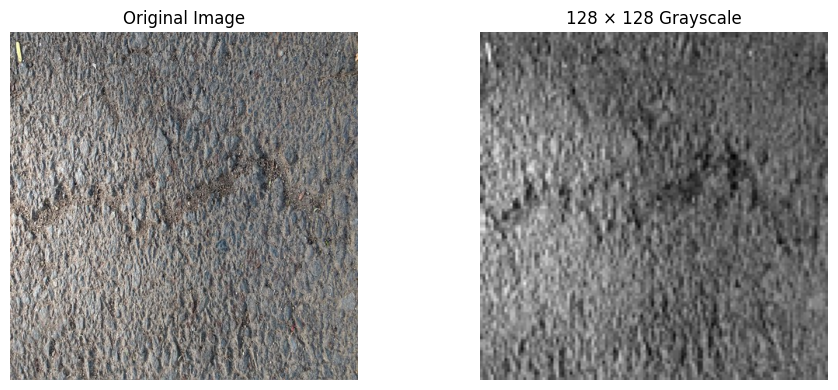

In [478]:
sample_path = crack_files[0]

# Open original image
original_img = Image.open(sample_path)

# Convert to grayscale and resize
sample_gray = preprocess_image(sample_path, IMAGE_SIZE)

# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_gray, cmap="gray")
plt.title("128 × 128 Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

In [479]:
# prpcess all images
images = []
labels = []
filenames = []

for filepath in crack_files:
    img_array = preprocess_image(filepath, IMAGE_SIZE)

    images.append(img_array)
    labels.append(1)
    filenames.append(os.path.basename(filepath))

for filepath in non_crack_files:
    img_array = preprocess_image(filepath, IMAGE_SIZE)

    images.append(img_array)
    labels.append(0)
    filenames.append(os.path.basename(filepath))

In [480]:
# convert to numpy array
X_images = np.array(images)
y_images = np.array(labels)

# check labels
print("Number of crack images:", np.sum(y_images == 1))
print("Number of non-crack images:", np.sum(y_images == 0))

Number of crack images: 200
Number of non-crack images: 200


In [481]:
# areate function
def extract_intensity_features(gray_image):
    
    # Convert image to floating point for calculations
    pixels = gray_image.astype(np.float64)
    
    # Flatten 2D image into 1D array
    pixels = pixels.flatten()
    
    # Basic statistics
    mean_brightness = np.mean(pixels)
    std_intensity = np.std(pixels)
    variance = np.var(pixels)
    min_intensity = np.min(pixels)
    max_intensity = np.max(pixels)
    median_intensity = np.median(pixels)
    
    # Dark and bright pixel ratios
    dark_ratio = np.mean(pixels < 50)
    bright_ratio = np.mean(pixels > 200)
    
    return {
        "mean_brightness": mean_brightness,
        "std_intensity": std_intensity,
        "variance": variance,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity,
        "dark_ratio": dark_ratio,
        "bright_ratio": bright_ratio
    }

    # test on one image
    features = extract_intensity_features(X_images[0])

# print(features)

In [482]:
feature_rows = []

for image in X_images:
    features = extract_intensity_features(image)
    feature_rows.append(features)

image_features_df = pd.DataFrame(feature_rows)
image_features_df.head()

,mean_brightness,std_intensity,variance,min_intensity,max_intensity,median_intensity,dark_ratio,bright_ratio
0,122.085083,25.113693,630.697595,42.0,234.0,120.0,0.000305,0.002686
1,131.831848,19.940848,397.637435,30.0,219.0,133.0,0.001404,0.001038
2,121.172485,24.277407,589.392490,4.0,225.0,121.0,0.006775,0.002747
3,130.120239,19.731231,389.321480,41.0,255.0,131.0,0.000305,0.001526
4,131.076355,19.815623,392.658904,40.0,255.0,132.0,0.000610,0.002258


In [483]:
image_features_df["label"] = y_images
print(image_features_df.shape)

# add file names
image_features_df.insert(0, "filename", filenames)
display(image_features_df.drop(columns=["filename", "label"]).describe().T)

# compare cracks vs non-cracks
grouped_features = image_features_df.groupby("label").mean(numeric_only=True)
display(grouped_features)

(400, 9)


,count,mean,std,min,25%,50%,75%,max
mean_brightness,400.0,150.873916,17.756734,110.349792,134.368576,152.751953,166.010727,189.697815
std_intensity,400.0,20.830510,6.925746,10.434267,15.024902,19.588995,24.974604,42.857227
variance,400.0,481.756175,332.545162,108.873934,225.747836,383.728835,623.730888,1836.741918
min_intensity,400.0,64.885000,36.748373,0.000000,36.000000,68.000000,98.250000,130.000000
max_intensity,400.0,241.057500,13.486248,191.000000,233.000000,245.000000,253.000000,255.000000
median_intensity,400.0,151.045000,17.771820,111.000000,135.750000,153.000000,166.000000,190.000000
dark_ratio,400.0,0.001942,0.005643,0.000000,0.000000,0.000000,0.000732,0.054749
bright_ratio,400.0,0.027080,0.038393,0.000000,0.002869,0.008850,0.039047,0.230774


,mean_brightness,std_intensity,variance,min_intensity,max_intensity,median_intensity,dark_ratio,bright_ratio
label,,,,,,,,
0,157.503142,17.079395,311.435596,90.28,235.710,157.245,0.000015,0.014915
1,144.244691,24.581624,652.076753,39.49,246.405,144.845,0.003870,0.039246


In [484]:
def extract_canny_features(gray_image, low_threshold=50, high_threshold=150):
    edges = cv2.Canny(gray_image, low_threshold, high_threshold)
    
    # Count edge pixels
    edge_count = np.sum(edges > 0)
    
    # Total number of pixels
    total_pixels = edges.size
    
    # Proportion of pixels classified as edges
    edge_density = edge_count / total_pixels
    
    return edges, edge_count, edge_density

In [485]:
edge_counts = []
edge_densities = []

for image in X_images:
    edges, edge_count, edge_density = extract_canny_features(
        image, low_threshold=50, high_threshold=150)
    
    edge_counts.append(edge_count)
    edge_densities.append(edge_density)

image_features_df["edge_count"] = edge_counts
image_features_df["edge_density"] = edge_densities

# compare edge difference between classes
edge_comparison = image_features_df.groupby("label")[
    ["edge_count", "edge_density"] ].mean()

display(edge_comparison)

,edge_count,edge_density
label,,
0,4230.835,0.258230
1,5672.950,0.346249


In [486]:
# save csv
image_features_df.to_csv(
    "image_features.csv",
    index=False)

## Train the model

In [487]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import time

In [488]:
feature_columns = [
    "mean_brightness",
    "std_intensity",
    "variance",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "dark_ratio",
    "bright_ratio",
    "edge_count",
    "edge_density"
]

X = image_features_df[feature_columns]
y = image_features_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 10)
y shape: (400,)


In [489]:
# train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [490]:
# create models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1)
}

In [491]:
# train models and note training times
trained_models = {}
training_times = {}

for name, model in models.items():
    start_time = time.perf_counter()
    model.fit(X_train_scaled, y_train)

    end_time = time.perf_counter()
    training_time = end_time - start_time

    trained_models[name] = model
    training_times[name] = training_time

    print(name)
    print(f"Training time: {training_time:.6f} seconds")

Logistic Regression
Training time: 0.008023 seconds
Decision Tree
Training time: 0.002021 seconds
Random Forest
Training time: 0.152446 seconds


In [492]:
# note prediction time
predictions = {}
prediction_times = {}

for name, model in trained_models.items():
    start_time = time.perf_counter()
    y_pred = model.predict(X_test_scaled)

    end_time = time.perf_counter()
    prediction_time = end_time - start_time

    predictions[name] = y_pred
    prediction_times[name] = prediction_time

    print(name)
    print(f"Prediction time: {prediction_time:.6f} seconds")

Logistic Regression
Prediction time: 0.002550 seconds
Decision Tree
Prediction time: 0.000604 seconds
Random Forest
Prediction time: 0.033186 seconds


In [493]:
# calculate all metrices
results = []

for name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test, y_pred, zero_division=0)

    recall = recall_score(
        y_test, y_pred, zero_division=0)

    f1 = f1_score(
        y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Training Time (s)": training_times[name],
        "Prediction Time (s)": prediction_times[name]
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9000,0.921053,0.875,0.897436,0.008023,0.002550
1,Decision Tree,0.9375,0.948718,0.925,0.936709,0.002021,0.000604
2,Random Forest,0.9375,0.926829,0.950,0.938272,0.152446,0.033186


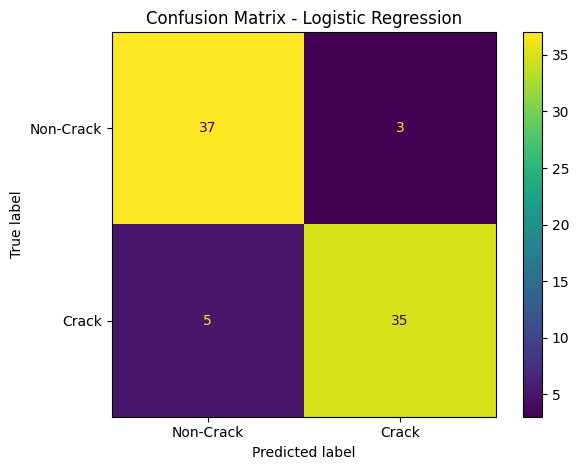

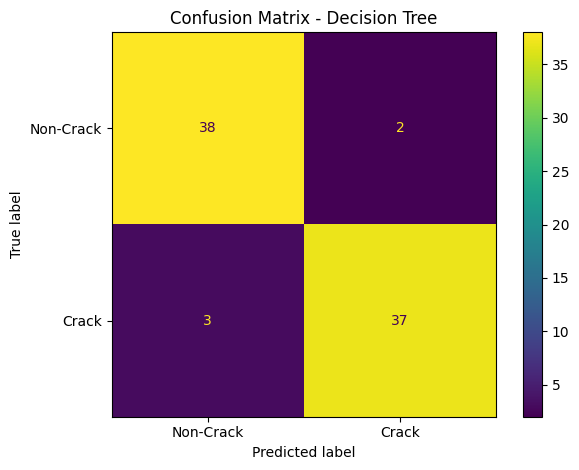

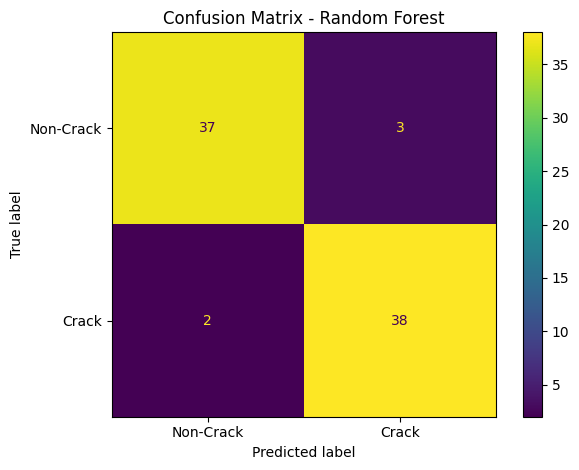

In [494]:
# confusion matrices
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Crack", "Crack"] )

    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()

    filename = (name.lower().replace(" ", "_") + "_confusion_matrix.png")
    plt.savefig(f"{filename}", dpi=150, bbox_inches="tight")

    plt.show()
    plt.close()

In [495]:
# extract imporved canny features
def extract_improved_canny_features(
    gray_image,
    low_threshold=30,
    high_threshold=100
):

    edges = cv2.Canny(gray_image, low_threshold, high_threshold)    
    edge_count = np.sum(edges > 0)
    total_pixels = edges.size
    edge_density = edge_count / total_pixels
    return edges, edge_count, edge_density


# extract features from all images
improved_edge_counts = []
improved_edge_densities = []

for image in X_images:
    edges, edge_count, edge_density = extract_improved_canny_features(
        image,
        low_threshold=30,
        high_threshold=100)
    
    improved_edge_counts.append(edge_count)
    improved_edge_densities.append(edge_density)

In [496]:
# improved feature table
improved_image_features_df = image_features_df.copy()

improved_image_features_df["edge_count"] = improved_edge_counts
improved_image_features_df["edge_density"] = improved_edge_densities

# comparision
print("Original Canny features:")

display(
    image_features_df[
        ["edge_count", "edge_density"]
    ].describe()
)

print("\nImproved Canny features:")

display(
    improved_image_features_df[
        ["edge_count", "edge_density"]
    ].describe()
)

Original Canny features:


,edge_count,edge_density
count,400.000000,400.000000
mean,4951.892500,0.302240
std,1382.106471,0.084357
min,1307.000000,0.079773
25%,3874.750000,0.236496
50%,5621.000000,0.343079
75%,6028.000000,0.367920
max,6400.000000,0.390625



Improved Canny features:


,edge_count,edge_density
count,400.000000,400.000000
mean,5938.130000,0.362435
std,346.075771,0.021123
min,4379.000000,0.267273
25%,5717.000000,0.348938
50%,6051.000000,0.369324
75%,6206.500000,0.378815
max,6452.000000,0.393799


In [497]:
# improved X and y
X_improved = improved_image_features_df[feature_columns]
y_improved = improved_image_features_df["label"]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42,
    stratify=y_improved )

In [498]:
# scaling
scaler_imp = StandardScaler()

X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

In [499]:
# train the same models 
improved_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1)
}

In [500]:
improved_predictions = {}
improved_training_times = {}
improved_prediction_times = {}

for name, model in improved_models.items():
    # Training time
    start_time = time.perf_counter()
    model.fit(X_train_imp_scaled, y_train_imp)
    end_time = time.perf_counter()
    improved_training_times[name] = end_time - start_time

    # Prediction time
    start_time = time.perf_counter()
    y_pred = model.predict(X_test_imp_scaled)
    end_time = time.perf_counter()
    improved_prediction_times[name] = end_time - start_time
    improved_predictions[name] = y_pred

In [501]:
# improved metrices
improved_results = []

for name, y_pred in improved_predictions.items():
    improved_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_imp, y_pred),
        "Precision": precision_score(y_test_imp, y_pred, zero_division=0),
        "Recall": recall_score(y_test_imp, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test_imp, y_pred, zero_division=0),

        "Training Time (s)": improved_training_times[name],
        "Prediction Time (s)": improved_prediction_times[name]
    })

improved_results_df = pd.DataFrame(improved_results)
display(improved_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9000,0.9211,0.875,0.8974,0.0078,0.0002
1,Decision Tree,0.9375,0.9487,0.925,0.9367,0.0018,0.0002
2,Random Forest,0.9250,0.9048,0.950,0.9268,0.1130,0.0288


In [502]:
# compare original vs improved
original_results = results_df.copy()
original_results["Representation"] = "Original Canny (50/150)"

improved_results_comparison = improved_results_df.copy()
improved_results_comparison["Representation"] = "Improved Canny (30/100)"

comparison_df = pd.concat(
    [original_results,
     improved_results_comparison],
    ignore_index=True
)

comparison_df = comparison_df[
    ["Representation",
     "Model",
     "Accuracy",
     "Precision",
     "Recall",
     "F1-Score",
     "Training Time (s)",
     "Prediction Time (s)"
    ]
]

display(comparison_df.round(4))

,Representation,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Original Canny (50/150),Logistic Regression,0.9000,0.9211,0.875,0.8974,0.0080,0.0025
1,Original Canny (50/150),Decision Tree,0.9375,0.9487,0.925,0.9367,0.0020,0.0006
2,Original Canny (50/150),Random Forest,0.9375,0.9268,0.950,0.9383,0.1524,0.0332
3,Improved Canny (30/100),Logistic Regression,0.9000,0.9211,0.875,0.8974,0.0078,0.0002
4,Improved Canny (30/100),Decision Tree,0.9375,0.9487,0.925,0.9367,0.0018,0.0002
5,Improved Canny (30/100),Random Forest,0.9250,0.9048,0.950,0.9268,0.1130,0.0288


# PART-B

In [503]:
# Load dataset
df_email = pd.read_csv("emails.csv")

display(df_email.head())

print("shape:", df_email.shape)

print("\nColumn names:")
print(df_email.columns.tolist())

df_email.info()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


shape: (5172, 3002)

Column names:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'l

In [504]:
# missing value
print(df_email.isnull().sum())

print("\n", df_email["Prediction"].value_counts())

print("\nClass percentages:")
print(df_email["Prediction"].value_counts(normalize=True) * 100)

# Check data types
print("\ndata types: \n",df_email.dtypes.value_counts())

# unique values for email number
print("\nFirst column:")
print(df_email.columns[0])

print("\nUnique email numbers:")
print(df_email.iloc[:, 0].nunique())

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

 Prediction
0    3672
1    1500
Name: count, dtype: int64

Class percentages:
Prediction
0    70.99768
1    29.00232
Name: proportion, dtype: float64

data types: 
 int64     3001
object       1
Name: count, dtype: int64

First column:
Email No.

Unique email numbers:
5172


In [505]:
# Remove the ID column
id_column = df_email.columns[0]

df_model = df_email.drop(columns=[id_column])

# Features
X_email = df_model.drop(columns=["Prediction"])

# Target
y_email = df_model["Prediction"]

print("X shape:", X_email.shape)
print("y shape:", y_email.shape)

print("\nTarget distribution:")
print(y_email.value_counts())

X shape: (5172, 3000)
y shape: (5172,)

Target distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


In [506]:
# train test split
X_train_email, X_test_email, y_train_email, y_test_email = train_test_split(
    X_email,
    y_email,
    test_size=0.20,
    random_state=42,
    stratify=y_email
)

print("Training data:", X_train_email.shape)
print("Testing data:", X_test_email.shape)

Training data: (4137, 3000)
Testing data: (1035, 3000)


In [507]:
email_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [508]:
# train the models and note training time
email_trained_models = {}
email_training_times = {}

for name, model in email_models.items():
    start_time = time.perf_counter()
    model.fit(X_train_email, y_train_email)
    end_time = time.perf_counter()
    training_time = end_time - start_time
    email_trained_models[name] = model
    email_training_times[name] = training_time

    print(f"{name} training time: {training_time:.4f} seconds")

Logistic Regression training time: 5.1409 seconds
Decision Tree training time: 0.7206 seconds
Random Forest training time: 0.4147 seconds


In [509]:
# prediction and note prediction time
email_predictions = {}
email_prediction_times = {}

for name, model in email_trained_models.items():
    start_time = time.perf_counter()
    y_pred = model.predict(X_test_email)
    end_time = time.perf_counter()
    prediction_time = end_time - start_time
    email_predictions[name] = y_pred
    email_prediction_times[name] = prediction_time

    print(f"{name} prediction time: {prediction_time:.4f} seconds")

Logistic Regression prediction time: 0.0355 seconds
Decision Tree prediction time: 0.0128 seconds
Random Forest prediction time: 0.0415 seconds


In [510]:
# calculate metrices
email_results = []

for name, y_pred in email_predictions.items():
    accuracy = accuracy_score(y_test_email, y_pred)
    precision = precision_score(y_test_email, y_pred, zero_division=0)
    recall = recall_score(y_test_email, y_pred, zero_division=0)
    f1 = f1_score(y_test_email, y_pred, zero_division=0)

    email_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Training Time (s)": email_training_times[name],
        "Prediction Time (s)": email_prediction_times[name]
    })

email_results_df = pd.DataFrame(email_results)

display(email_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9826,0.9578,0.9833,0.9704,5.1409,0.0355
1,Decision Tree,0.9188,0.8699,0.8467,0.8581,0.7206,0.0128
2,Random Forest,0.9643,0.9340,0.9433,0.9386,0.4147,0.0415


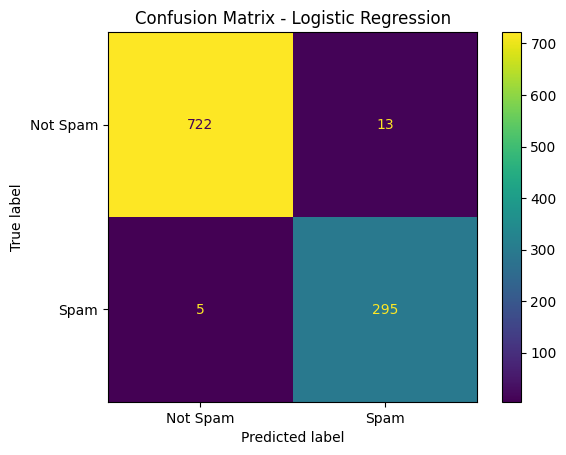

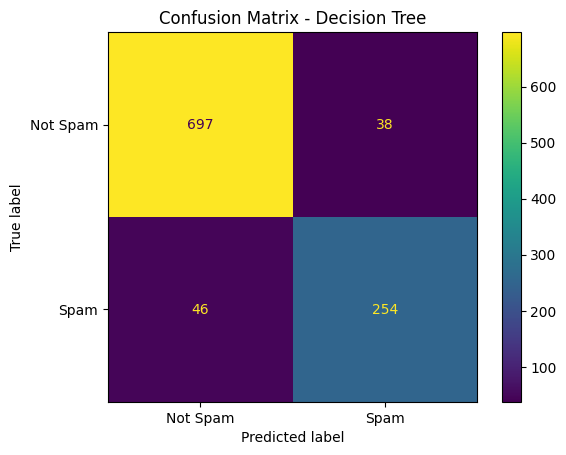

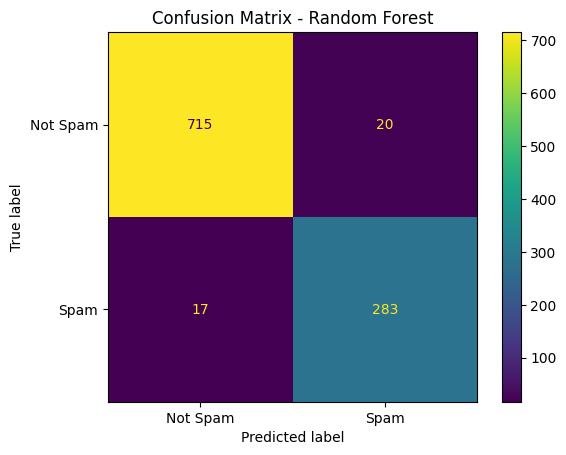

In [511]:
# confusiion matrix and save it
for name, y_pred in email_predictions.items():
    cm = confusion_matrix(y_test_email, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Spam", "Spam"] )

    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    filename = name.lower().replace(" ", "_")
    plt.savefig(
        f"email_confusion_matrix_{filename}.png",
        dpi=150,
        bbox_inches="tight")

    plt.show()

# PART-C

### improvement for PART-A

In [512]:
# check edge-density change
edge_comparison = pd.DataFrame({
    "Original Edge Density": image_features_df["edge_density"],
    "Improved Edge Density": improved_image_features_df["edge_density"]
})

edge_comparison["Change"] = (
    edge_comparison["Improved Edge Density"]
    - edge_comparison["Original Edge Density"] )

display(edge_comparison.head())

# change the average
print("Average original edge density:",
       image_features_df["edge_density"].mean() )

print("Average improved edge density:",
       improved_image_features_df["edge_density"].mean() )

print("Average change:",
       (improved_image_features_df["edge_density"].mean()
        - image_features_df["edge_density"].mean() )
)

,Original Edge Density,Improved Edge Density,Change
0,0.350525,0.367065,0.016541
1,0.326294,0.371887,0.045593
2,0.300415,0.353027,0.052612
3,0.360291,0.378784,0.018494
4,0.333557,0.363037,0.029480


Average original edge density: 0.3022395324707031
Average improved edge density: 0.3624346923828125
Average change: 0.060195159912109386


In [513]:
# change in F1 score
original_f1 = (results_df
    .set_index("Model")["F1-Score"] )

improved_f1 = (improved_results_df
    .set_index("Model")["F1-Score"] )

f1_comparison = pd.DataFrame({
    "Original F1": original_f1,
    "Improved F1": improved_f1 })

f1_comparison["F1 Change"] = (
    f1_comparison["Improved F1"]
    - f1_comparison["Original F1"] )

display(f1_comparison.round(4))

,Original F1,Improved F1,F1 Change
Model,,,
Logistic Regression,0.8974,0.8974,0.0000
Decision Tree,0.9367,0.9367,0.0000
Random Forest,0.9383,0.9268,-0.0114


### improvement for PART-B

In [514]:
from sklearn.feature_selection import SelectKBest, chi2

# Select top 500 features
selector = SelectKBest(score_func=chi2, k=500)

# Fit only on training data
X_train_selected = selector.fit_transform(X_train_email, y_train_email)

# Transform test data using the SAME selector
X_test_selected = selector.transform(X_test_email)

print("Original training shape:", X_train_email.shape)
print("Improved training shape:", X_train_selected.shape)

print("\nOriginal testing shape:", X_test_email.shape)
print("Improved testing shape:", X_test_selected.shape)

Original training shape: (4137, 3000)
Improved training shape: (4137, 500)

Original testing shape: (1035, 3000)
Improved testing shape: (1035, 500)


In [515]:
improved_email_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1)
}

In [516]:
# train
improved_email_trained_models = {}
improved_email_training_times = {}

print("Training time: ")
for name, model in improved_email_models.items():
    start_time = time.perf_counter()
    model.fit(X_train_selected, y_train_email)
    end_time = time.perf_counter()
    training_time = end_time - start_time
    improved_email_trained_models[name] = model
    improved_email_training_times[name] = training_time

    print(
        f"  {name} : "
        f"{training_time:.4f}"
    )

print()

# make predictions
improved_email_predictions = {}
improved_email_prediction_times = {}

print("Prediction time: ")
for name, model in improved_email_trained_models.items():
    start_time = time.perf_counter()
    y_pred = model.predict(X_test_selected)
    end_time = time.perf_counter()
    prediction_time = end_time - start_time
    improved_email_predictions[name] = y_pred
    improved_email_prediction_times[name] = prediction_time
    print(
        f"  {name} : "
        f"{prediction_time:.4f}"
    )

Training time: 
  Logistic Regression : 1.6732
  Decision Tree : 0.1848
  Random Forest : 0.2646

Prediction time: 
  Logistic Regression : 0.0020
  Decision Tree : 0.0011
  Random Forest : 0.0291


In [517]:
# Store improved results
improved_email_results = []

for name, y_pred in improved_email_predictions.items():
    improved_email_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_email, y_pred),
        "Precision": precision_score(y_test_email, y_pred, zero_division=0),
        "Recall": recall_score(y_test_email, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test_email, y_pred, zero_division=0),
        "Training Time (s)": improved_email_training_times[name],
        "Prediction Time (s)": improved_email_prediction_times[name]
    })

improved_email_results_df = pd.DataFrame(improved_email_results)
display(improved_email_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9652,0.9342,0.9467,0.9404,1.6732,0.0020
1,Decision Tree,0.9314,0.8855,0.8767,0.8811,0.1848,0.0011
2,Random Forest,0.9662,0.9316,0.9533,0.9423,0.2646,0.0291


In [518]:
# comparision
# Original results
original_email_comparison = email_results_df[
    ["Model",
     "Accuracy",
     "Precision",
     "Recall",
     "F1-Score",
     "Training Time (s)",
     "Prediction Time (s)"]
].copy()

original_email_comparison.insert(
    0, "Representation", "Original (3000 features)")

# Improved results
improved_email_comparison = improved_email_results_df[
    ["Model",
     "Accuracy",
     "Precision",
     "Recall",
     "F1-Score",
     "Training Time (s)",
     "Prediction Time (s)"]
].copy()

improved_email_comparison.insert(
    0, "Representation", "Improved (500 features)")

# Combine
email_representation_comparison = pd.concat(
    [original_email_comparison, improved_email_comparison],
    ignore_index=True
)

display(email_representation_comparison.round(4) )

,Representation,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Original (3000 features),Logistic Regression,0.9826,0.9578,0.9833,0.9704,5.1409,0.0355
1,Original (3000 features),Decision Tree,0.9188,0.8699,0.8467,0.8581,0.7206,0.0128
2,Original (3000 features),Random Forest,0.9643,0.9340,0.9433,0.9386,0.4147,0.0415
3,Improved (500 features),Logistic Regression,0.9652,0.9342,0.9467,0.9404,1.6732,0.0020
4,Improved (500 features),Decision Tree,0.9314,0.8855,0.8767,0.8811,0.1848,0.0011
5,Improved (500 features),Random Forest,0.9662,0.9316,0.9533,0.9423,0.2646,0.0291
